In [2]:
from mc_experiment import (
    make_seed_counter,
    next_seed,
    standardize_innovations,
    summarize_reference_experiment,
    summarize_mle_augmentation_experiment,
    augmented_config_path,
)

from SymbolicDSGE import ModelParser, DSGESolver, Shock
from SymbolicDSGE.bayesian import make_prior

from numpy import log
import numpy as np

from scipy.stats import chi2, gaussian_kde, norm

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [3]:
# Load reference model
parser = ModelParser("../../MODELS/misspec_test/reference.yaml")
config, kalman = parser.get_all()
solver = DSGESolver(config, kalman)

comp = solver.compile(
    n_state=3,
    n_exog=3,
)
sol = solver.solve(
    comp,
    steady_state=[0.0, 0.0, 0.0, 0.0, 0.0],
)

print("Transition matrix:\n", sol.A.round(3), "\n")
print("Shock Loadings:\n", sol.B.round(3))

Transition matrix:
 [[ 0.83   0.     0.     0.     0.   ]
 [ 0.     0.85   0.     0.     0.   ]
 [ 0.288 -0.047  0.28   0.     0.   ]
 [ 0.892  0.708 -1.711  0.     0.   ]
 [ 0.7   -0.115 -1.363  0.     0.   ]] 

Shock Loadings:
 [[ 1.     0.     0.   ]
 [ 0.     1.     0.   ]
 [ 0.     0.     1.   ]
 [ 3.193  0.493 -6.107]
 [ 2.531 -0.406 -4.864]]


In [4]:
# Load Misspecified DGP
parser_dgp = ModelParser("../../MODELS/misspec_test/misspec.yaml")
config_dgp, kalman_dgp = parser_dgp.get_all()
solver_dgp = DSGESolver(config_dgp, kalman_dgp)
comp_dgp = solver_dgp.compile(
    n_state=3,
    n_exog=3,
)
sol_dgp = solver_dgp.solve(
    comp_dgp,
    steady_state=[0.0, 0.0, 0.0, 0.0, 0.0],
)

In [5]:
T=100_000
# Large sample simulations used to approximate measurement-noise variances
_large_sample_seed_counter = make_seed_counter(start=100_000)
shocks_large = {
    "g,z": Shock(T, "norm", multivar=True, seed=next_seed(_large_sample_seed_counter)).shock_generator(),
    "r": Shock(T, "norm", multivar=False, seed=next_seed(_large_sample_seed_counter)).shock_generator(),
}

sim1 = sol_dgp.sim(
    T=T,
    shocks=shocks_large,
    observables=True,
)
sim2 = sol.sim(
    T=T,
    shocks=shocks_large,
    observables=True,
)

y = np.column_stack([sim1["OutGap"], sim1["Infl"], sim1["Rate"]])

In [6]:
kf_misspec = sol.kalman(
    y=y,
    filter_mode="linear",
    estimate_R_diag=False,
    R=np.zeros((3, 3), dtype=np.float64),
    return_shocks=True,
)
kf_dgp = sol_dgp.kalman(
    y=y,
    filter_mode="linear",
    estimate_R_diag=False,
    R=np.zeros((3, 3), dtype=np.float64),
    return_shocks=True,
)

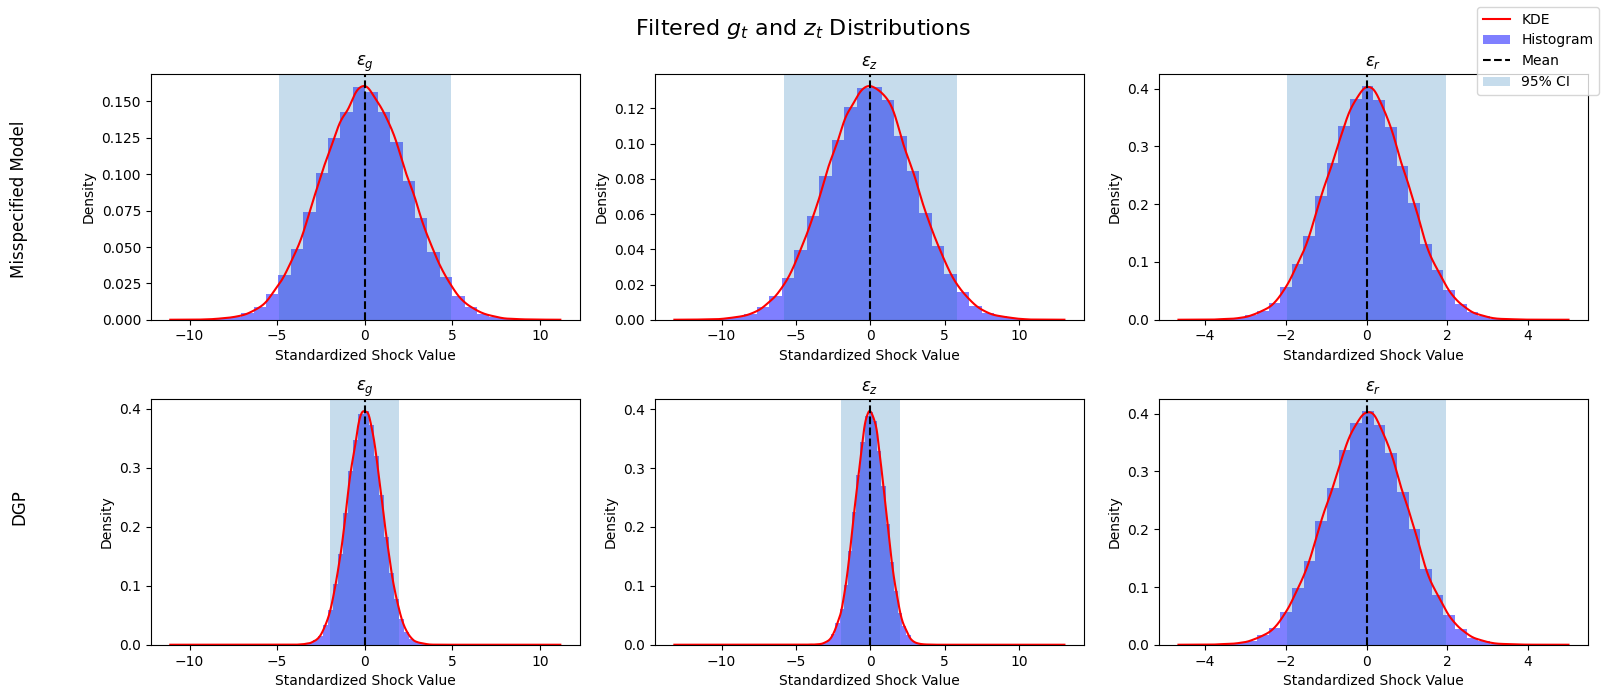

: 

In [ ]:
gzr_misspec = kf_misspec.eps_hat
gzr_dgp = kf_dgp.eps_hat

# Standardization relative to population covariance
true_std = np.array([0.18, 0.64, 0.18])
true_corr_coeff = np.array([
    [1.0, 0.36, 0.0],
    [0.36, 1.0, 0.0],
    [0.0, 0.0, 1.0],
])

implied_covariance = np.outer(true_std, true_std) * true_corr_coeff
L = np.linalg.cholesky(implied_covariance)
L_inv = np.linalg.inv(L)

gzr_misspec = (gzr_misspec - gzr_misspec.mean(axis=0)) @ L_inv.T
gzr_dgp = (gzr_dgp - gzr_dgp.mean(axis=0)) @ L_inv.T

g_range_kde = np.linspace(
    min(gzr_misspec[:, 0].min(), gzr_dgp[:, 0].min()) - 0.5,
    max(gzr_misspec[:, 0].max(), gzr_dgp[:, 0].max()) + 0.5,
    1000,
)
z_range_kde = np.linspace(
    min(gzr_misspec[:, 1].min(), gzr_dgp[:, 1].min()) - 0.5,
    max(gzr_misspec[:, 1].max(), gzr_dgp[:, 1].max()) + 0.5,
    1000,
)
r_range_kde = np.linspace(
    min(gzr_misspec[:, 2].min(), gzr_dgp[:, 2].min()) - 0.5,
    max(gzr_misspec[:, 2].max(), gzr_dgp[:, 2].max()) + 0.5,
    1000,
)

g_misspec_kde = gaussian_kde(gzr_misspec[:, 0])
z_misspec_kde = gaussian_kde(gzr_misspec[:, 1])
r_misspec_kde = gaussian_kde(gzr_misspec[:, 2])

g_dgp_kde = gaussian_kde(gzr_dgp[:, 0])
z_dgp_kde = gaussian_kde(gzr_dgp[:, 1])
r_dgp_kde = gaussian_kde(gzr_dgp[:, 2])

fig, axes = plt.subplots(2, 3, figsize=(16, 7))

# Means and 95% intervals
g_misspec_mean = gzr_misspec[:, 0].mean()
g_misspec_ci = np.percentile(gzr_misspec[:, 0], [2.5, 97.5])

z_misspec_mean = gzr_misspec[:, 1].mean()
z_misspec_ci = np.percentile(gzr_misspec[:, 1], [2.5, 97.5])

r_misspec_mean = gzr_misspec[:, 2].mean()
r_misspec_ci = np.percentile(gzr_misspec[:, 2], [2.5, 97.5])

g_dgp_mean = gzr_dgp[:, 0].mean()
g_dgp_ci = np.percentile(gzr_dgp[:, 0], [2.5, 97.5])

z_dgp_mean = gzr_dgp[:, 1].mean()
z_dgp_ci = np.percentile(gzr_dgp[:, 1], [2.5, 97.5])

r_dgp_mean = gzr_dgp[:, 2].mean()
r_dgp_ci = np.percentile(gzr_dgp[:, 2], [2.5, 97.5])

axes[0, 0].plot(g_range_kde, g_misspec_kde(g_range_kde), label="KDE", color="red")
axes[0, 0].hist(gzr_misspec[:, 0], bins=30, density=True, alpha=0.5, label="Histogram", color="blue")
axes[0, 0].axvline(g_misspec_mean, color="black", linestyle="--", label="Mean")
axes[0, 0].axvspan(g_misspec_ci[0], g_misspec_ci[1], alpha=0.25, label="95% CI")

axes[0, 1].plot(z_range_kde, z_misspec_kde(z_range_kde), label="KDE", color="red")
axes[0, 1].hist(gzr_misspec[:, 1], bins=30, density=True, alpha=0.5, label="Histogram", color="blue")
axes[0, 1].axvline(z_misspec_mean, color="black", linestyle="--", label="Mean")
axes[0, 1].axvspan(z_misspec_ci[0], z_misspec_ci[1], alpha=0.25, label="95% CI")

axes[0, 2].plot(r_range_kde, r_misspec_kde(r_range_kde), label="KDE", color="red")
axes[0, 2].hist(gzr_misspec[:, 2], bins=30, density=True, alpha=0.5, label="Histogram", color="blue")
axes[0, 2].axvline(r_misspec_mean, color="black", linestyle="--", label="Mean")
axes[0, 2].axvspan(r_misspec_ci[0], r_misspec_ci[1], alpha=0.25, label="95% CI")

axes[1, 0].plot(g_range_kde, g_dgp_kde(g_range_kde), label="KDE", color="red")
axes[1, 0].hist(gzr_dgp[:, 0], bins=30, density=True, alpha=0.5, label="Histogram", color="blue")
axes[1, 0].axvline(g_dgp_mean, color="black", linestyle="--", label="Mean")
axes[1, 0].axvspan(g_dgp_ci[0], g_dgp_ci[1], alpha=0.25, label="95% CI")

axes[1, 1].plot(z_range_kde, z_dgp_kde(z_range_kde), label="KDE", color="red")
axes[1, 1].hist(gzr_dgp[:, 1], bins=30, density=True, alpha=0.5, label="Histogram", color="blue")
axes[1, 1].axvline(z_dgp_mean, color="black", linestyle="--", label="Mean")
axes[1, 1].axvspan(z_dgp_ci[0], z_dgp_ci[1], alpha=0.25, label="95% CI")

axes[1, 2].plot(r_range_kde, r_dgp_kde(r_range_kde), label="KDE", color="red")
axes[1, 2].hist(gzr_dgp[:, 2], bins=30, density=True, alpha=0.5, label="Histogram", color="blue")
axes[1, 2].axvline(r_dgp_mean, color="black", linestyle="--", label="Mean")
axes[1, 2].axvspan(r_dgp_ci[0], r_dgp_ci[1], alpha=0.25, label="95% CI")

# Column titles
axes[0, 0].set_title(r"$\epsilon_g$")
axes[0, 1].set_title(r"$\epsilon_z$")
axes[0, 2].set_title(r"$\epsilon_r$")

axes[1, 0].set_title(r"$\epsilon_g$")
axes[1, 1].set_title(r"$\epsilon_z$")
axes[1, 2].set_title(r"$\epsilon_r$")

for ax in axes.flat:
    ax.set_xlabel("Standardized Shock Value")
    ax.set_ylabel("Density")


# Row labels as vertical titles
fig.text(
    0.01, 0.72,
    "Misspecified Model",
    va="center",
    ha="center",
    rotation="vertical",
    fontsize=12
)

fig.text(
    0.01, 0.28,
    "DGP",
    va="center",
    ha="center",
    rotation="vertical",
    fontsize=12
)

# Deduplicate legend labels
handles, labels = [], []
for ax in axes.flat:
    h, l = ax.get_legend_handles_labels()
    for handle, label in zip(h, l):
        if label not in labels:
            handles.append(handle)
            labels.append(label)

fig.legend(handles, labels, loc="upper right")

# Leave room on the left for the vertical row labels and the title at the top
plt.tight_layout(rect=[0.04, 0, 1, 0.95])
plt.suptitle("Filtered $g_t$ and $z_t$ Distributions", fontsize=16)
plt.show()

In [20]:
# Covariance matrices
print("Covariance of filtered shocks under misspecified model:\n", np.cov(gzr_misspec.T).round(3))
print("\nCovariance of filtered shocks under DGP:\n", np.cov(gzr_dgp.T).round(3))

true_std = np.array([0.18, 0.64, 0.18])
true_corr_coeff = np.array([
    [1.0, 0.36, 0.0],
    [0.36, 1.0, 0.0],
    [0.0, 0.0, 1.0],
])

implied_covariance = np.outer(true_std, true_std) * true_corr_coeff
print("\nTrue covariance matrix:\n", implied_covariance.round(3))

Covariance of filtered shocks under misspecified model:
 [[ 0.203  0.967 -0.051]
 [ 0.967  5.309 -0.318]
 [-0.051 -0.318  0.033]]

Covariance of filtered shocks under DGP:
 [[ 0.032  0.041  0.   ]
 [ 0.041  0.409 -0.001]
 [ 0.    -0.001  0.033]]

True covariance matrix:
 [[0.032 0.041 0.   ]
 [0.041 0.41  0.   ]
 [0.    0.    0.032]]


0.4096